# Дифференцирование

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html#matplotlib.pyplot.axhline
* https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p
* https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html
* https://en.wikipedia.org/wiki/Finite_difference
* https://pythonnumericalmethods.berkeley.edu/notebooks/chapter20.02-Finite-Difference-Approximating-Derivatives.html
* https://en.wikipedia.org/wiki/Gradient_descent
* https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html
* https://zhang-yang.medium.com/the-gradient-argument-in-pytorchs-backward-function-explained-by-examples-68f266950c29

In [1]:
# Используемые библиотеки
import sympy as sp
import math
import numpy as np
import matplotlib.pyplot as plt
import torch as th

## Задачи для совместного разбора

1\. Дана функция $f(x) = x^2$. Найдите производную этой функции различными способами

In [2]:
x = sp.Symbol('x')
f = x**2
f.diff(x)

2*x

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дана функция $f(x)$. Найдите (аналитически) производную данной функции $f'(x)$ и реализуйте две этих функции. Постройте в одной системе координат графики $f(x)$, $f'(x)$ и $g(x) = 0$ на отрезке [1, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [3]:
def f(x):
  return (math.sin(x))/(math.log(x)+1)

In [4]:
def diff_f(x):
  return (((math.cos(x))*(math.log(x)+1)) - ((math.sin(x))/x)) / ((math.log(x)+1)**2)

In [5]:
def g(x):
  return 0

In [6]:
# Плотная сетка на отрезке [1, 10] для гладких графиков
points = np.linspace(1, 10, 500)
points_f = np.array([f(float(x)) for x in points])
points_diff = np.array([diff_f(float(x)) for x in points])
points_g = np.zeros_like(points)

print("Интервал:", (points[0], points[-1]))
print("Количество точек:", len(points))


Интервал: (np.float64(1.0), np.float64(10.0))
Количество точек: 500


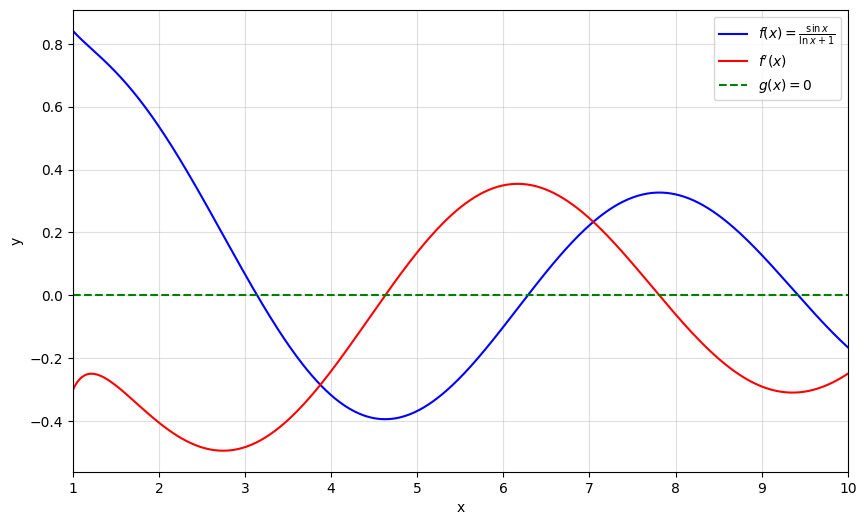

In [7]:

plt.figure(figsize=(10, 6))
plt.plot(points, points_f, color='blue',
         label=r'$f(x)=\frac{\sin x}{\ln x+1}$')
plt.plot(points, points_diff, color='red',
         label=r"$f'(x)$")
plt.plot(points, points_g, color='green', linestyle='--',
         label=r'$g(x)=0$')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.4)
plt.legend()
plt.xlim(1, 10)
plt.show()


<p class="task" id="2"></p>

2\. Дана функция $f(x)$. Найдите (численно) производную данной функции $f'(x)$ на отрезке [1, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [8]:
def f(x):
    return np.sin(x) / (np.log(x) + 1)

In [9]:
def simple_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

In [10]:
x = np.linspace(1, 10, 1000)
y = f(x)
y_prime = simple_derivative(f, x)
g = np.zeros_like(x)

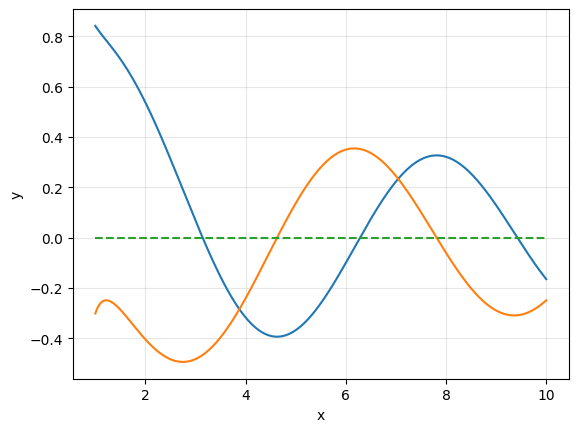

In [11]:
plt.plot(x, y)
plt.plot(x, y_prime)
plt.plot(x, g, linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)

<p class="task" id="3"></p>

3\. Найдите локальный минимум функции $f(x)$ при помощи метода градиентного спуска. В качестве начальной точки используйте $x_0 = 4$. Найдите локальный максимум этой же функции, используя в качестве начальной точки $x_0'=9$.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [12]:
def f(x):
    return np.sin(x) / (np.log(x) + 1)

In [13]:
def f_prime(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

In [14]:
def gradient_descent(f_prime, x0, learning_rate=0.1, max_iter=1000, tol=1e-6, mode='min'):
    x = x0
    history = [x]

    for i in range(max_iter):
        grad = f_prime(x)
        if mode == 'min':
            x_new = x - learning_rate * grad
        else:  # mode == 'max'
            x_new = x + learning_rate * grad
        if abs(x_new - x) < tol:
            break
        x = x_new
        history.append(x)
    return x, f(x), history

In [15]:
# Поиск локального минимума (x0 = 4)
x_min, f_min, history_min = gradient_descent(f_prime, x0=4, learning_rate=0.05, mode='min')

In [16]:
# Поиск локального максимума (x0 = 9)
x_max, f_max, history_max = gradient_descent(f_prime, x0=9, learning_rate=0.05, mode='max')

In [17]:
print(f"Локальный минимум:")
print(f"  x = {x_min:.6f}")
print(f"  f(x) = {f_min:.6f}")
print(f"  Количество итераций: {len(history_min)}")

print(f"\nЛокальный максимум:")
print(f"  x = {x_max:.6f}")
print(f"  f(x) = {f_max:.6f}")
print(f"  Количество итераций: {len(history_max)}")

Локальный минимум:
  x = 4.627190
  f(x) = -0.393520
  Количество итераций: 482

Локальный максимум:
  x = 7.812175
  f(x) = 0.326973
  Количество итераций: 615


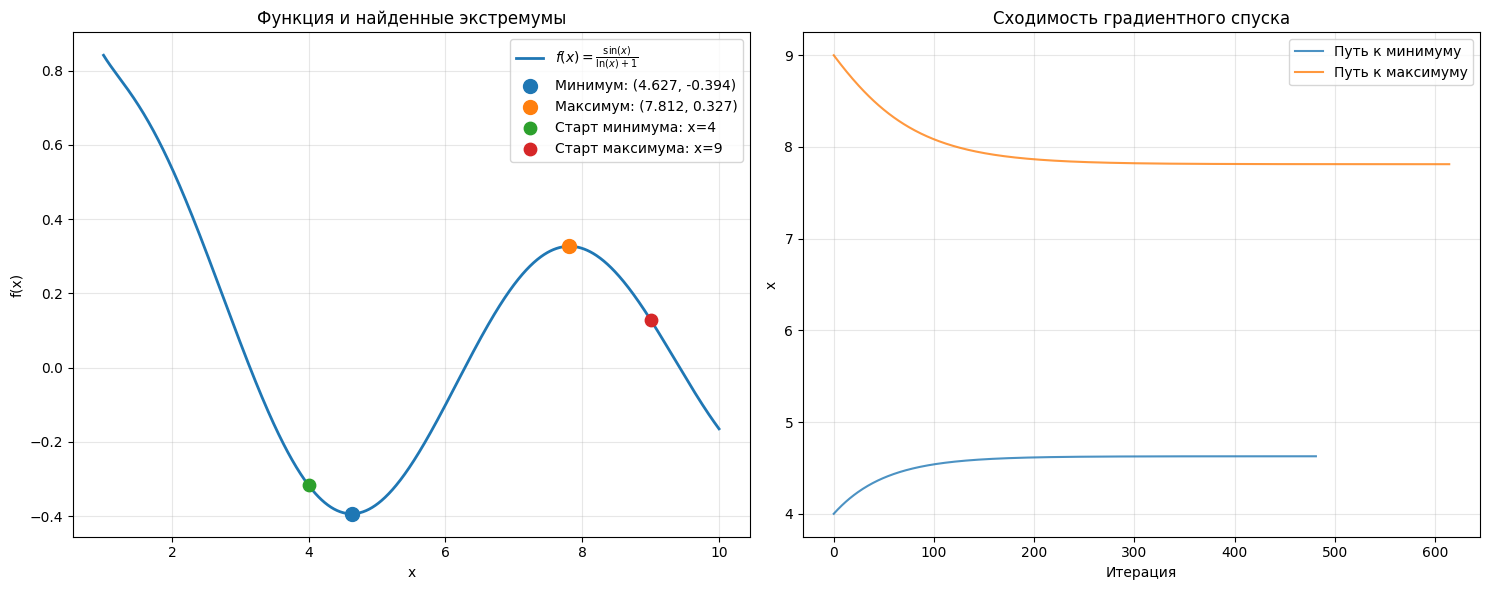


АНАЛИЗ РАЗНЫХ СКОРОСТЕЙ ОБУЧЕНИЯ
LR=0.01: минимум(4.6144, -0.3935) за 1001 итер., максимум(7.8666, 0.3265) за 1001 итер.
LR=0.05: минимум(4.6272, -0.3935) за 482 итер., максимум(7.8122, 0.3270) за 615 итер.
LR=0.1: минимум(4.6272, -0.3935) за 257 итер., максимум(7.8121, 0.3270) за 327 итер.
LR=0.2: минимум(4.6272, -0.3935) за 135 итер., максимум(7.8121, 0.3270) за 172 итер.


In [18]:

def visualize_optimization(history_min, history_max):
    x_vals = np.linspace(1, 10, 1000)
    y_vals = f(x_vals)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Функция и найденные экстремумы
    ax1.plot(x_vals, y_vals, linewidth=2,
             label=r'$f(x)=\frac{\sin(x)}{\ln(x)+1}$')
    ax1.scatter(x_min, f_min, s=100, zorder=5,
                label=f'Минимум: ({x_min:.3f}, {f_min:.3f})')
    ax1.scatter(x_max, f_max, s=100, zorder=5,
                label=f'Максимум: ({x_max:.3f}, {f_max:.3f})')
    ax1.scatter(4, f(4), s=80, zorder=5, label='Старт минимума: x=4')
    ax1.scatter(9, f(9), s=80, zorder=5, label='Старт максимума: x=9')
    ax1.set_xlabel('x')
    ax1.set_ylabel('f(x)')
    ax1.set_title('Функция и найденные экстремумы')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Сходимость метода
    ax2.plot(range(len(history_min)), history_min,
             label='Путь к минимуму', alpha=0.8)
    ax2.plot(range(len(history_max)), history_max,
             label='Путь к максимуму', alpha=0.8)
    ax2.set_xlabel('Итерация')
    ax2.set_ylabel('x')
    ax2.set_title('Сходимость градиентного спуска')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_optimization(history_min, history_max)

# Дополнительная проверка влияния learning rate
print("\n" + "=" * 50)
print("АНАЛИЗ РАЗНЫХ СКОРОСТЕЙ ОБУЧЕНИЯ")
print("=" * 50)

learning_rates = [0.01, 0.05, 0.1, 0.2]
for lr in learning_rates:
    x_min_lr, f_min_lr, hist_min = gradient_descent(
        f_prime, 4, learning_rate=lr, mode='min'
    )
    x_max_lr, f_max_lr, hist_max = gradient_descent(
        f_prime, 9, learning_rate=lr, mode='max'
    )
    print(
        f"LR={lr}: минимум({x_min_lr:.4f}, {f_min_lr:.4f}) "
        f"за {len(hist_min)} итер., максимум({x_max_lr:.4f}, {f_max_lr:.4f}) "
        f"за {len(hist_max)} итер."
    )


<p class="task" id="4"></p>

4\. Дана функция $f(x)$. Найдите (используя возможности по автоматическому дифференцированию пакета `torch`) производную данной функции $f'(x)$ на отрезке [0, 10]. Постройте в одной системе координат график $f(x)$, $f'(x)$ и $g(x) = 0$ на полуинтервале (0, 10]. Изобразите графики различными цветами и включите сетку.

$$f(x) = \frac{sin(x)}{\ln(x) + 1}$$

- [ ] Проверено на семинаре

In [19]:
import torch

In [20]:
def f_torch(x):
    return torch.sin(x) / (torch.log(x) + 1)

In [21]:

def compute_derivative_torch(f, x_values):
    """Производная f по x сразу для набора независимых точек."""
    x_tensor = torch.as_tensor(x_values, dtype=torch.float64).clone().detach()
    x_tensor.requires_grad_(True)
    y_tensor = f(x_tensor)
    gradients = torch.autograd.grad(
        outputs=y_tensor,
        inputs=x_tensor,
        grad_outputs=torch.ones_like(y_tensor),
        create_graph=False
    )[0]
    return gradients.detach().cpu().numpy()


In [22]:
# Внутри (0, 10] есть точка разрыва:
# ln(x) + 1 = 0  =>  x = exp(-1).
singularity = float(np.exp(-1))
eps = 1e-4

x_left = np.linspace(eps, singularity - eps, 1200)
x_right = np.linspace(singularity + eps, 10.0, 3000)

print(f"Точка разрыва x = e^(-1) = {singularity:.9f}")


Точка разрыва x = e^(-1) = 0.367879441


In [23]:

with torch.no_grad():
    y_left = f_torch(torch.tensor(x_left, dtype=torch.float64)).numpy()
    y_right = f_torch(torch.tensor(x_right, dtype=torch.float64)).numpy()


In [24]:

dy_left = compute_derivative_torch(f_torch, x_left)
dy_right = compute_derivative_torch(f_torch, x_right)


In [25]:

g_left = np.zeros_like(x_left)
g_right = np.zeros_like(x_right)


In [26]:

def stationary_points_from_grid(x_grid, derivative_grid):
    """Приближённо находит смены знака производной внутри непрерывного участка."""
    idx = np.where(np.signbit(derivative_grid[:-1]) != np.signbit(derivative_grid[1:]))[0]
    return x_grid[idx]

stationary_left = stationary_points_from_grid(x_left, dy_left)
stationary_right = stationary_points_from_grid(x_right, dy_right)
stationary_points = np.concatenate([stationary_left, stationary_right])

print("Приближённые стационарные точки:",
      np.round(stationary_points, 6).tolist())


Приближённые стационарные точки: [4.626752, 7.809591]


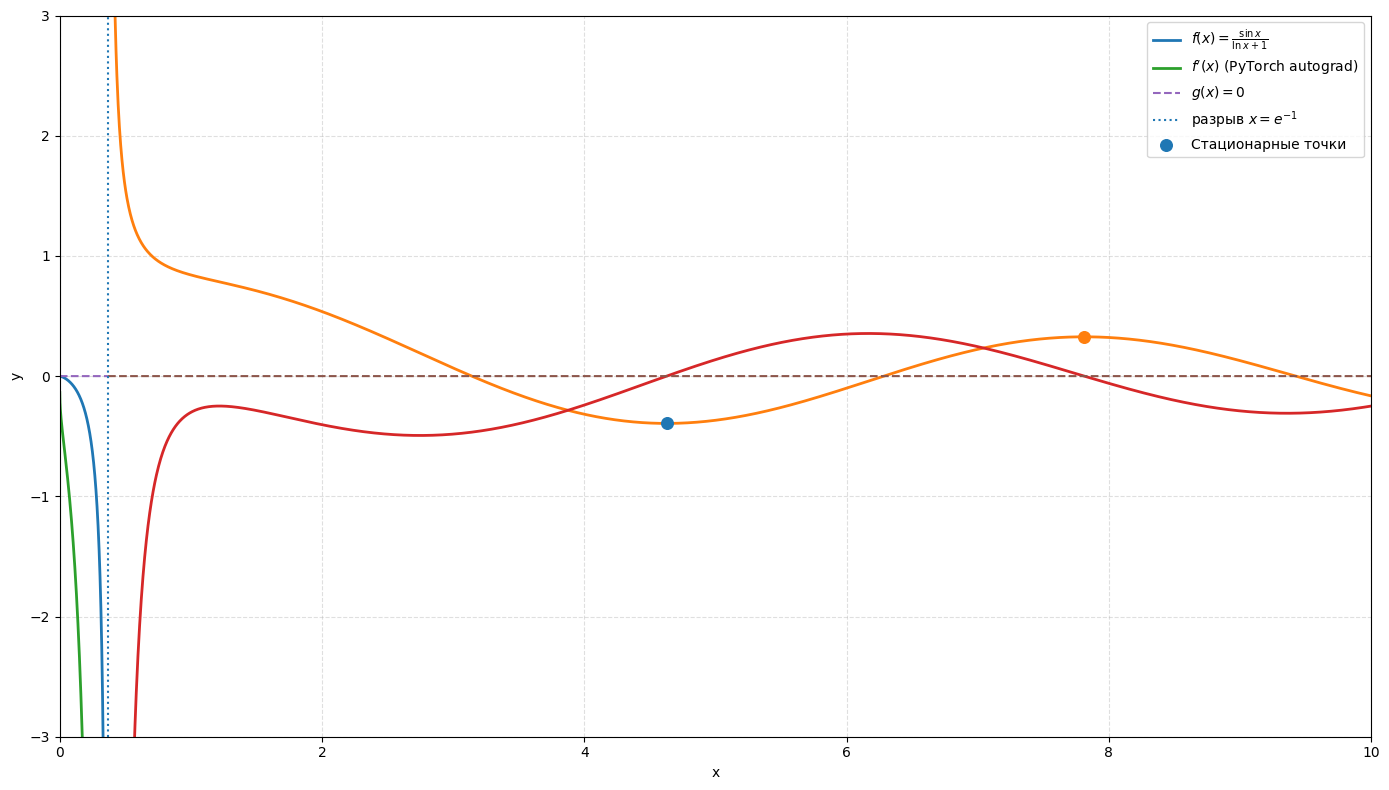

АВТОМАТИЧЕСКОЕ ДИФФЕРЕНЦИРОВАНИЕ НА (0, 10]
Область определения на рассматриваемом промежутке: (0, e^(-1)) ∪ (e^(-1), 10], где e^(-1) ≈ 0.367879441
В окрестности x=e^(-1) функция и её производная неограничены, поэтому конечные min/max по дискретной сетке не являются областью значений.
Количество найденных стационарных точек: 2
Стационарные точки (по сетке): [4.626752, 7.809591]

Сравнение autograd с численной производной:
x		AutoDiff	Numerical	Difference
------------------------------------------------------------
0.1		-1.352257	-1.352257	2.44e-09
1.0		-0.301169	-0.301169	8.91e-11
2.0		-0.404377	-0.404377	4.80e-12
5.0		0.136872	0.136872	5.48e-12
8.0		-0.060290	-0.060290	1.96e-12


In [27]:
plt.figure(figsize=(14, 8))
plt.plot(x_left, y_left, linewidth=2,
         label=r'$f(x)=\frac{\sin x}{\ln x+1}$')
plt.plot(x_right, y_right, linewidth=2)
plt.plot(x_left, dy_left, linewidth=2,
         label=r"$f'(x)$ (PyTorch autograd)")
plt.plot(x_right, dy_right, linewidth=2)
plt.plot(x_left, g_left, linestyle='--', linewidth=1.5,
         label=r'$g(x)=0$')
plt.plot(x_right, g_right, linestyle='--', linewidth=1.5)

plt.axvline(singularity, linestyle=':', linewidth=1.5,
            label=r'разрыв $x=e^{-1}$')

for j, x0 in enumerate(stationary_points):
    y0 = f_torch(torch.tensor(x0, dtype=torch.float64)).item()
    plt.scatter(x0, y0, s=70, zorder=5,
                label='Стационарные точки' if j == 0 else None)

plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 10)
plt.ylim(-3, 3)
plt.grid(True, alpha=0.4, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

print("=" * 70)
print("АВТОМАТИЧЕСКОЕ ДИФФЕРЕНЦИРОВАНИЕ НА (0, 10]")
print("=" * 70)
print(
    "Область определения на рассматриваемом промежутке: "
    f"(0, e^(-1)) ∪ (e^(-1), 10], где e^(-1) ≈ {singularity:.9f}"
)
print(
    "В окрестности x=e^(-1) функция и её производная неограничены, "
    "поэтому конечные min/max по дискретной сетке не являются областью значений."
)
print("Количество найденных стационарных точек:", len(stationary_points))
print("Стационарные точки (по сетке):",
      np.round(stationary_points, 6).tolist())

def numerical_derivative_task4(x, h=1e-5):
    """Центральная разность в float64 для независимой проверки autograd."""
    xp = torch.tensor(x + h, dtype=torch.float64)
    xm = torch.tensor(x - h, dtype=torch.float64)
    return ((f_torch(xp) - f_torch(xm)) / (2 * h)).item()

test_points = [0.1, 1.0, 2.0, 5.0, 8.0]
print("\nСравнение autograd с численной производной:")
print("x\t\tAutoDiff\tNumerical\tDifference")
print("-" * 60)
for x_point in test_points:
    auto_diff = compute_derivative_torch(f_torch, [x_point])[0]
    num_diff = numerical_derivative_task4(x_point)
    print(
        f"{x_point:.1f}\t\t{auto_diff:.6f}\t"
        f"{num_diff:.6f}\t{abs(auto_diff-num_diff):.2e}"
    )


<p class="task" id="5"></p>

5\. Дана функция $f(x)$. Найдите производную данной функции $f'(x)$ на отрезке [0, 10] при помощи формулы производной сложной функции. На этом же отрезке найдите, используя возможности по автоматическому дифференцированию пакета `torch`. Сравните результаты.

$$f(x) = sin(cos(x))$$

- [ ] Проверено на семинаре

In [28]:
def g(x: th.Tensor) -> th.Tensor:
    return th.cos(x) # Внутренняя функция

def h(x: th.Tensor) -> th.Tensor:
    return th.sin(x) # Внешняя функция

def dfdg(x: th.Tensor) -> th.Tensor:
    return th.cos(x) # Производная внешней функции по внутренней: dh/dg = cos(g)

def dgdx(x: th.Tensor) -> th.Tensor:
    return -th.sin(x) # Производная внутренней функции по x: dg/dx = -sin(x)

def dfdx(x: th.Tensor) -> th.Tensor:
    g_x = g(x)
    return dfdg(g_x) * dgdx(x) # Производная сложной функции по правилу цепи: df/dx = df/dg * dg/dx

In [29]:

def autodiff_derivative(f, x_values):
    x_tensor = th.as_tensor(x_values, dtype=th.float64).clone().detach()
    x_tensor.requires_grad_(True)
    y_tensor = f(x_tensor)

    gradients = th.autograd.grad(
        outputs=y_tensor,
        inputs=x_tensor,
        grad_outputs=th.ones_like(y_tensor),
        create_graph=False
    )[0]
    return gradients.detach().cpu().numpy()


In [30]:
def f(x: th.Tensor) -> th.Tensor:
    return h(g(x))

In [31]:

x_values = np.linspace(0, 10, 1000)

x_tensor = th.tensor(x_values, dtype=th.float64)
y_values = f(x_tensor).detach().numpy()

analytic_deriv = dfdx(x_tensor).detach().numpy()
autodiff_deriv = autodiff_derivative(f, x_values)


СРАВНЕНИЕ МЕТОДОВ ВЫЧИСЛЕНИЯ ПРОИЗВОДНОЙ
Максимальная разница: 0.00e+00
Средняя разница:      0.00e+00

Сравнение в конкретных точках:
x		Аналитич.	Автодиф.	Разница
------------------------------------------------------------
0.50		-0.306359	-0.306359	0.00e+00
1.00		-0.721606	-0.721606	0.00e+00
2.00		-0.831692	-0.831692	0.00e+00
3.14		-0.000861	-0.000861	0.00e+00
5.00		0.920603	0.920603	0.00e+00
7.00		-0.478959	-0.478959	0.00e+00
9.00		-0.252568	-0.252568	0.00e+00


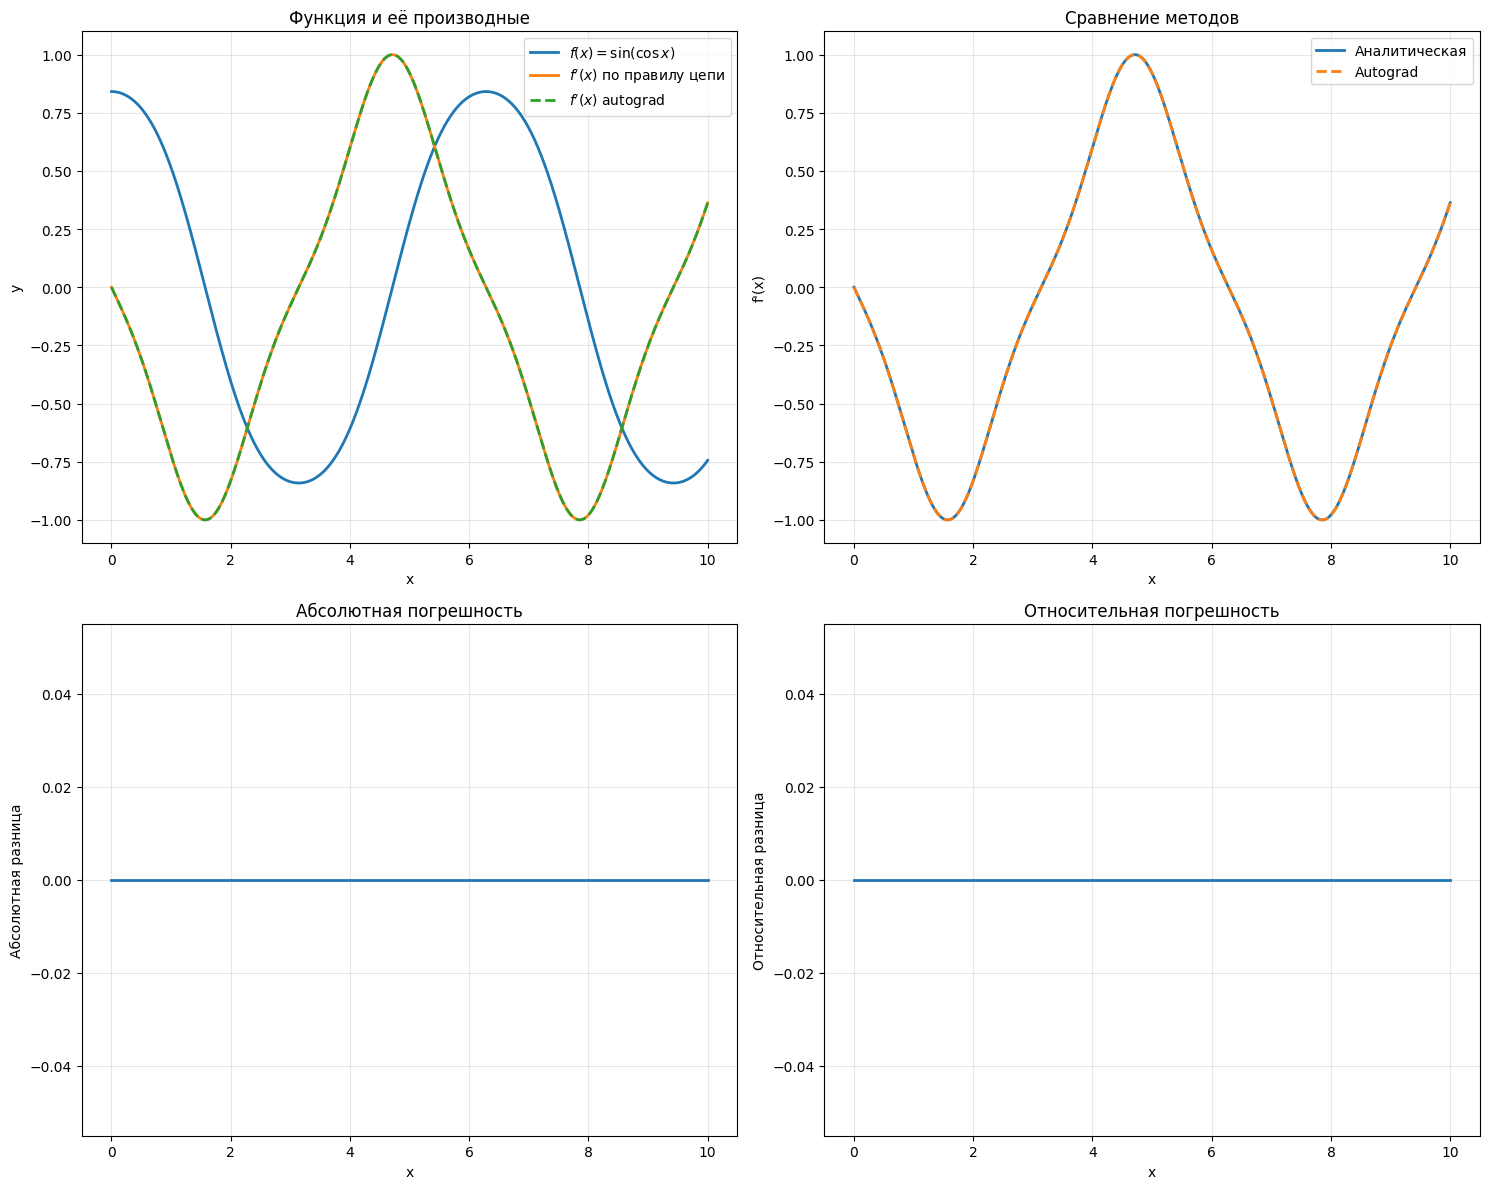

ДЕТАЛЬНЫЙ АНАЛИЗ ПРАВИЛА ЦЕПИ В ТОЧКЕ x = 2.0
g(x) = cos(2.0) = -0.416147
f(x) = sin(g(x)) = -0.404239
df/dg = cos(g(x)) = 0.914653
dg/dx = -sin(x) = -0.909297
df/dx = df/dg * dg/dx = -0.831692
Autograd: f'(2.0) = -0.831692
Разница: 0.00e+00

СРАВНЕНИЕ ТРЕХ МЕТОДОВ В РАЗНЫХ ТОЧКАХ
x		Аналитич.	Автодиф.	Численный	|A-AD|		|A-N|
----------------------------------------------------------------------------------------------------
0.10		-0.054359	-0.054359	-0.054359	0.00e+00	1.01e-11
1.00		-0.721606	-0.721606	-0.721606	0.00e+00	6.75e-12
2.00		-0.831692	-0.831692	-0.831692	0.00e+00	1.47e-11
3.14		-0.000861	-0.000861	-0.000861	0.00e+00	4.62e-12
4.50		0.955892	0.955892	0.955892	0.00e+00	6.49e-11
6.00		0.160211	0.160211	0.160211	0.00e+00	2.50e-13
8.00		-0.978904	-0.978904	-0.978904	0.00e+00	6.79e-11
10.00		0.363490	0.363490	0.363490	0.00e+00	2.56e-12


In [32]:
def compare_results():
    """Сравнение производной по правилу цепи и PyTorch autograd."""
    difference = np.abs(analytic_deriv - autodiff_deriv)

    print("=" * 70)
    print("СРАВНЕНИЕ МЕТОДОВ ВЫЧИСЛЕНИЯ ПРОИЗВОДНОЙ")
    print("=" * 70)
    print(f"Максимальная разница: {np.max(difference):.2e}")
    print(f"Средняя разница:      {np.mean(difference):.2e}")

    test_points = [0.5, 1.0, 2.0, 3.14, 5.0, 7.0, 9.0]
    print("\nСравнение в конкретных точках:")
    print("x\t\tАналитич.\tАвтодиф.\tРазница")
    print("-" * 60)

    for x_point in test_points:
        x_t = th.tensor(x_point, dtype=th.float64)
        analytic_val = dfdx(x_t).item()

        x_a = th.tensor(x_point, dtype=th.float64, requires_grad=True)
        y_a = f(x_a)
        y_a.backward()
        autodiff_val = x_a.grad.item()

        print(
            f"{x_point:.2f}\t\t{analytic_val:.6f}\t"
            f"{autodiff_val:.6f}\t{abs(analytic_val-autodiff_val):.2e}"
        )


def plot_comparison():
    """Графики функции, производной и погрешности."""
    difference = np.abs(analytic_deriv - autodiff_deriv)
    relative_diff = difference / np.maximum(np.abs(analytic_deriv), 1e-12)

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    ax1.plot(x_values, y_values, linewidth=2,
             label=r'$f(x)=\sin(\cos x)$')
    ax1.plot(x_values, analytic_deriv, linewidth=2,
             label=r"$f'(x)$ по правилу цепи")
    ax1.plot(x_values, autodiff_deriv, '--', linewidth=2,
             label=r"$f'(x)$ autograd")
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title('Функция и её производные')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(x_values, analytic_deriv, linewidth=2, label='Аналитическая')
    ax2.plot(x_values, autodiff_deriv, '--', linewidth=2, label='Autograd')
    ax2.set_xlabel('x')
    ax2.set_ylabel("f'(x)")
    ax2.set_title('Сравнение методов')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3.plot(x_values, difference, linewidth=2)
    ax3.set_xlabel('x')
    ax3.set_ylabel('Абсолютная разница')
    ax3.set_title('Абсолютная погрешность')
    ax3.grid(True, alpha=0.3)

    ax4.plot(x_values, relative_diff, linewidth=2)
    ax4.set_xlabel('x')
    ax4.set_ylabel('Относительная разница')
    ax4.set_title('Относительная погрешность')
    ax4.grid(True, alpha=0.3)

    if np.any(difference > 0):
        ax3.set_yscale('log')
    if np.any(relative_diff > 0):
        ax4.set_yscale('log')

    plt.tight_layout()
    plt.show()


def chain_rule_analysis():
    """Детальный анализ правила цепи в точке x=2."""
    x_point = 2.0
    x_tensor = th.tensor(x_point, dtype=th.float64)

    print("=" * 70)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ ПРАВИЛА ЦЕПИ В ТОЧКЕ x = 2.0")
    print("=" * 70)

    g_val = g(x_tensor).item()
    h_val = h(th.tensor(g_val, dtype=th.float64)).item()
    dfdg_val = dfdg(th.tensor(g_val, dtype=th.float64)).item()
    dgdx_val = dgdx(x_tensor).item()
    dfdx_val = dfdx(x_tensor).item()

    print(f"g(x) = cos({x_point}) = {g_val:.6f}")
    print(f"f(x) = sin(g(x)) = {h_val:.6f}")
    print(f"df/dg = cos(g(x)) = {dfdg_val:.6f}")
    print(f"dg/dx = -sin(x) = {dgdx_val:.6f}")
    print(f"df/dx = df/dg * dg/dx = {dfdx_val:.6f}")

    x_auto = th.tensor(x_point, dtype=th.float64, requires_grad=True)
    y_auto = f(x_auto)
    y_auto.backward()
    auto_deriv = x_auto.grad.item()
    print(f"Autograd: f'({x_point}) = {auto_deriv:.6f}")
    print(f"Разница: {abs(dfdx_val-auto_deriv):.2e}")

def numerical_derivative(f, x, h=1e-5):
    xp = th.tensor(x + h, dtype=th.float64)
    xm = th.tensor(x - h, dtype=th.float64)
    return ((f(xp) - f(xm)) / (2 * h)).item()


def triple_comparison():
    """Сравнение правила цепи, autograd и центральной разности."""
    test_points = [0.1, 1.0, 2.0, 3.14, 4.5, 6.0, 8.0, 10.0]

    print("\n" + "=" * 80)
    print("СРАВНЕНИЕ ТРЕХ МЕТОДОВ В РАЗНЫХ ТОЧКАХ")
    print("=" * 80)
    print("x\t\tАналитич.\tАвтодиф.\tЧисленный\t|A-AD|\t\t|A-N|")
    print("-" * 100)

    for x_point in test_points:
        analytic = dfdx(th.tensor(x_point, dtype=th.float64)).item()

        x_auto = th.tensor(x_point, dtype=th.float64, requires_grad=True)
        y_auto = f(x_auto)
        y_auto.backward()
        autodiff = x_auto.grad.item()

        numeric = numerical_derivative(f, x_point)

        print(
            f"{x_point:.2f}\t\t{analytic:.6f}\t{autodiff:.6f}\t"
            f"{numeric:.6f}\t{abs(analytic-autodiff):.2e}\t"
            f"{abs(analytic-numeric):.2e}"
        )


compare_results()
plot_comparison()
chain_rule_analysis()
triple_comparison()


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ